# K-Nearest Neighbors

In [6]:
import matplotlib.pylab as plt
import numpy as np
from sklearn.linear_model import SGDRegressor
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier, KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.datasets import make_blobs, make_moons, make_regression

## classifier

In [2]:
x, y = make_moons(n_samples=200, noise=0.17, random_state=42)

In [3]:
def plot_data(x, y, z):
    fig, ax = plt.subplots()
    ax.scatter(x, y, c=z)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    return fig, ax

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

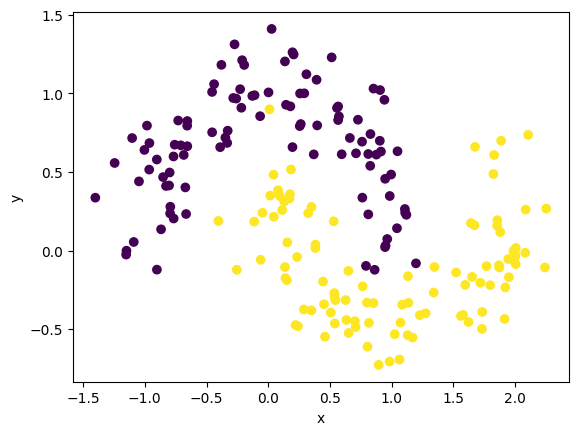

In [4]:
plot_data(x[:,0], x[:,1], y)

* KNeighborsClassifier

In [5]:
model = KNeighborsClassifier(n_neighbors=5, weights="uniform", algorithm="auto", metric="minkowski")
model.fit(x, y)
y_pred = model.predict(x)
model.score(x, y)

0.99

(21, 29) (21, 29) (609,) (21, 29)


Text(0, 0.5, 'y')

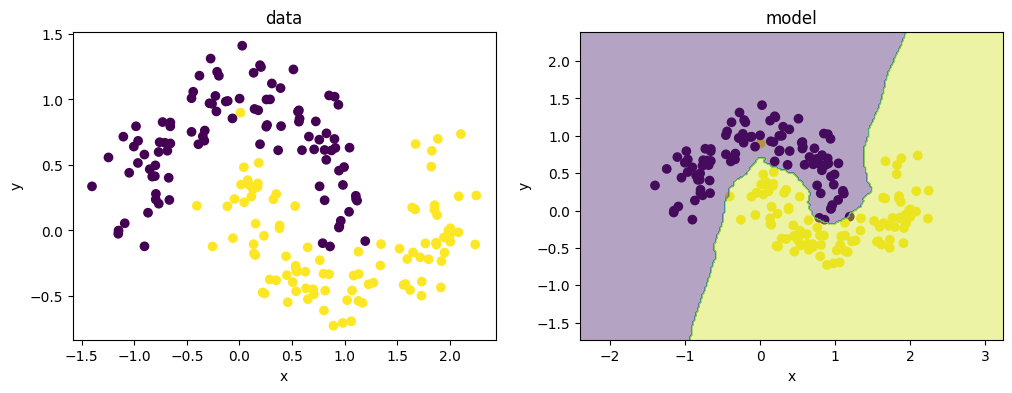

In [17]:
x_grid, y_grid = np.meshgrid(
    np.arange(x[:,0].min()-1, x[:,0].max()+1, 0.02),
    np.arange(x[:,1].min()-1, x[:,1].max()+1, 0.02)
    )
z_grid = model.predict(np.c_[x_grid.ravel(), y_grid.ravel()])
z_grid = z_grid.reshape(x_grid.shape)
#print(x_grid.shape, y_grid.shape, z.shape, y_plot.shape)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(x[:,0], x[:,1], c=y)
ax[0].set_title("data")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")

ax[1].scatter(x[:,0], x[:,1], c=y)
ax[1].contourf(x_grid, y_grid, z_grid, alpha=0.4)
ax[1].set_title("model")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")

* RadiusNeighborsClassifier

In [18]:
model = RadiusNeighborsClassifier(radius=1, weights="uniform", algorithm="auto", metric="minkowski", outlier_label=-1)
model.fit(x, y)
y_pred = model.predict(x)
model.score(x, y)

0.84

/home/fallou/mlpro/module_3/.venv/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:868: UserWarning: Outlier label -1 is not in training classes. All class probabilities of outliers will be assigned with 0.
  warnings.warn(


Text(0, 0.5, 'y')

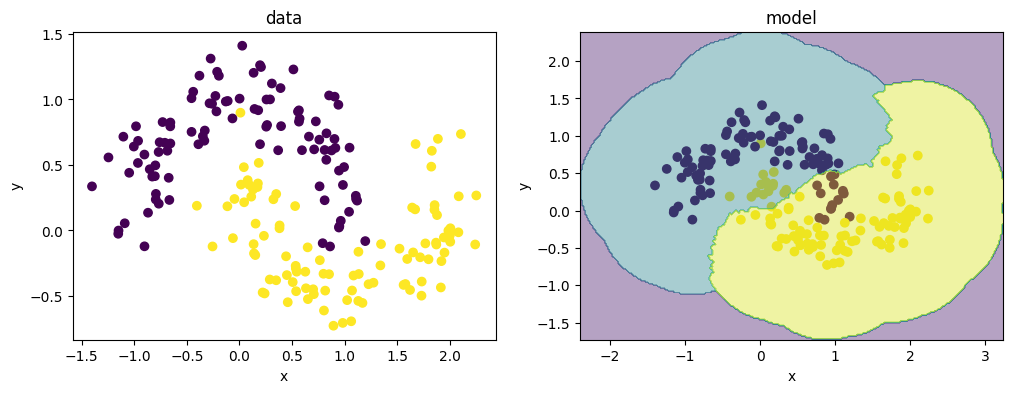

In [19]:
x_grid, y_grid = np.meshgrid(
    np.arange(x[:,0].min()-1, x[:,0].max()+1, 0.02),
    np.arange(x[:,1].min()-1, x[:,1].max()+1, 0.02)
    )
z_grid = model.predict(np.c_[x_grid.ravel(), y_grid.ravel()])
z_grid = z_grid.reshape(x_grid.shape)
#print(x_grid.shape, y_grid.shape, z.shape, y_plot.shape)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(x[:,0], x[:,1], c=y)
ax[0].set_title("data")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")

ax[1].scatter(x[:,0], x[:,1], c=y)
ax[1].contourf(x_grid, y_grid, z_grid, alpha=0.4)
ax[1].set_title("model")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")

## regressor

Text(0, 0.5, 'y')

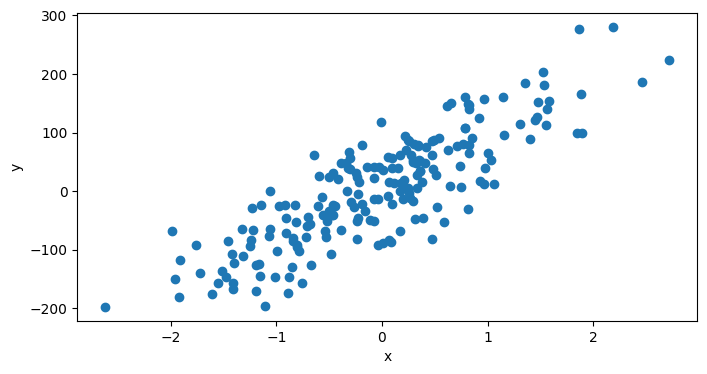

In [21]:
x, y = make_regression(n_samples=200, n_features=1, n_targets=1, noise=50, random_state=42)

plt.figure(figsize=(8,4))
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")

* KNeighborsRegressor

In [22]:
model = KNeighborsRegressor(n_neighbors=5, weights="uniform", algorithm="auto", leaf_size=30, p=2, metric="minkowski")
model.fit(x, y)
y_pred = model.predict(x)
model.score(x, y)

0.7553772413881581

Text(0.5, 1.0, 'KNeighborsRegressor')

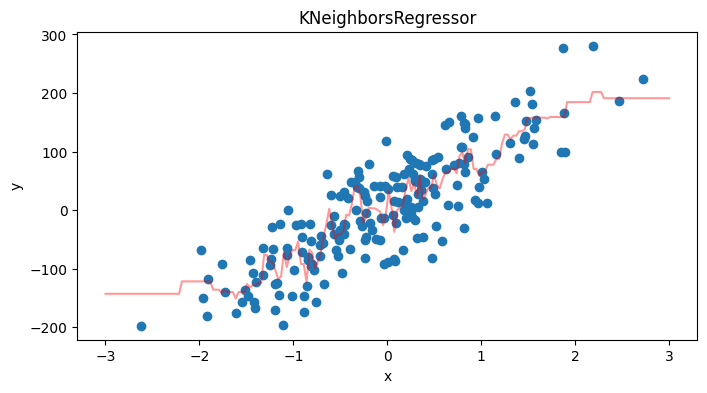

In [24]:
x_plot = np.linspace(-3, 3, 200).reshape(-1, 1)
y_plot = model.predict(x_plot)

plt.figure(figsize=(8, 4))
plt.scatter(x, y)
plt.plot(x_plot, y_plot, c="r", alpha=0.4)
plt.xlabel("x")
plt.ylabel("y")
plt.title("KNeighborsRegressor")

* RadiusNeighborsRegressor

In [25]:
model = RadiusNeighborsRegressor(radius=1, weights="uniform", algorithm="auto", leaf_size=30, p=2, metric="minkowski")

model.fit(x, y)
y_pred = model.predict(x)
model.score(x, y)

0.6608187255074478

Text(0.5, 1.0, 'RadiusNeighborsRegressor')

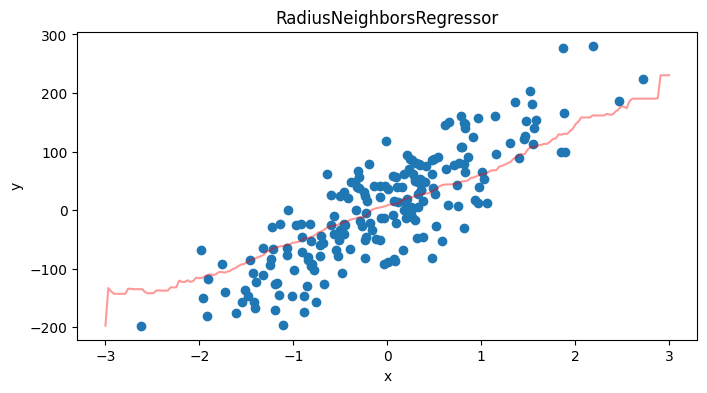

In [26]:
x_plot = np.linspace(-3, 3, 200).reshape(-1, 1)
y_plot = model.predict(x_plot)

plt.figure(figsize=(8, 4))
plt.scatter(x, y)
plt.plot(x_plot, y_plot, c="r", alpha=0.4)
plt.xlabel("x")
plt.ylabel("y")
plt.title("RadiusNeighborsRegressor")

* SGDRegressor (modele lineaire)

In [106]:
model = SGDRegressor()
model.fit(x, y)
y_pred = model.predict(x)
model.score(x, y)

0.7145816970468233

Text(0.5, 1.0, 'SGDRegressor')

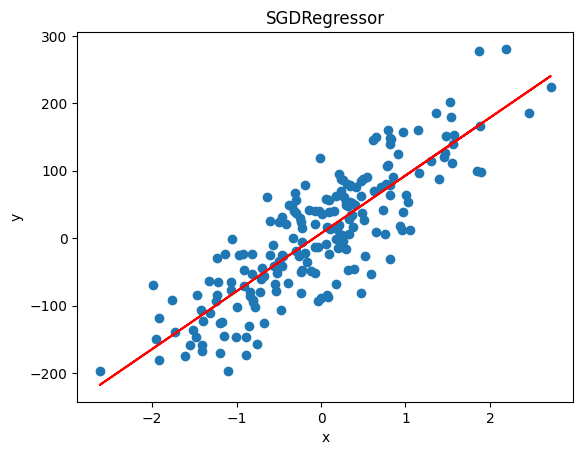

In [107]:
plt.scatter(x, y)
plt.plot(x, y_pred, c="r")
plt.xlabel("x")
plt.ylabel("y")
plt.title("SGDRegressor")